## Speech Emotion Recognition



### 1. Library and Data Import

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import copy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay


### 2. Exploratory Data Analysis

#### 2.1 Load Raw Data and Check for Empty Values

In [ ]:
# Path for saving/loading trained models
trained_models_path = '/content/drive/MyDrive/ECE_Emotion_Models/'

# Load in Full Data path and partial data path(CREMA)
# Check for NaNs
raw_full_path = '/content/drive/MyDrive/emotion.csv'
df_raw_full = pd.read_csv(raw_full_path)
print(df_raw_full.isna().sum())

crema_df_path = '/content/drive/MyDrive/processed_crema.csv'
crema_df = pd.read_csv(crema_df_path)
print(crema_df.isna().sum())


0               0
1               0
2               0
3               0
4               0
            ...  
2372        37624
2373        37624
2374        37624
2375        37624
Emotions        0
Length: 2377, dtype: int64
0           0
1           0
2           0
3           0
4           0
           ..
2372        0
2373        0
2374        0
2375        0
Emotions    0
Length: 2377, dtype: int64


#### 2.2 Dataset Target Value Counts Distribution

/tmp/ipykernel_12075/3345347608.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=full_counts.index, y=full_counts.values, palette="Blues_d")


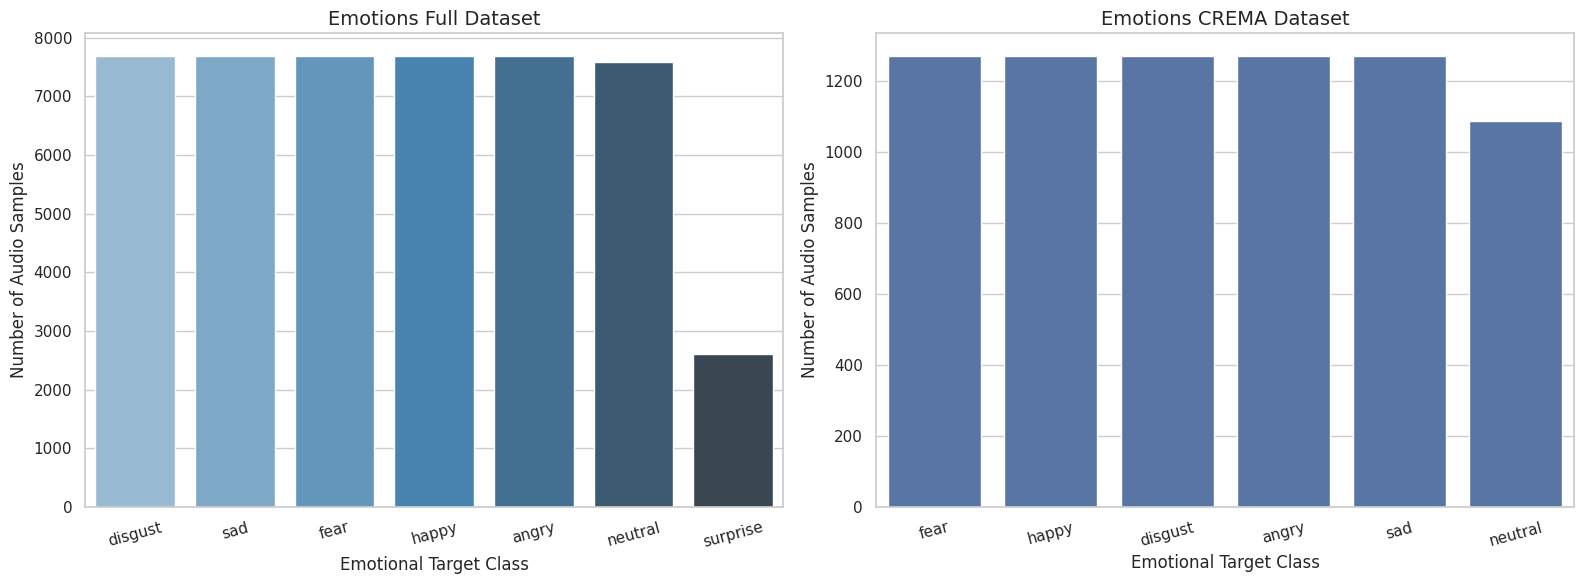

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
full_counts = df_raw_full['Emotions'].value_counts()
sns.barplot(x=full_counts.index, y=full_counts.values, palette="Blues_d")
plt.title("Emotions Full Dataset", fontsize=14)
plt.xlabel("Emotional Target Class", fontsize=12)
plt.ylabel("Number of Audio Samples", fontsize=12)
plt.xticks(rotation=15)

plt.subplot(1, 2, 2)
crema_counts = crema_df['Emotions'].value_counts()
sns.barplot(x=crema_counts.index, y=crema_counts.values)
plt.title("Emotions CREMA Dataset", fontsize=14)
plt.xlabel("Emotional Target Class", fontsize=12)
plt.ylabel("Number of Audio Samples", fontsize=12)
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

#### 2.2 Checking for Distribution of Target Variable

In [ ]:
df_raw_full['Emotions'].value_counts()

,count
Emotions,
disgust,7692
sad,7692
fear,7692
happy,7692
angry,7692
neutral,7580
surprise,2608


In [ ]:
crema_df['Emotions'].value_counts()

,count
Emotions,
fear,1271
happy,1271
disgust,1271
angry,1271
sad,1271
neutral,1087


#### 2.3 Verifying DataFrame Dimensions

In [ ]:
df_raw_full.head()

,0,1,2,3,4,5,6,7,8,9,...,2367,2368,2369,2370,2371,2372,2373,2374,2375,Emotions
0,0.343750,0.479492,0.573730,0.458008,0.375488,0.301758,0.269043,0.255371,0.251465,0.251953,...,-1.517691,-1.716481,-1.599312,-1.234615,-0.693200,-0.038981,0.675205,1.405603,2.112302,surprise
1,0.249512,0.371094,0.494629,0.487305,0.450195,0.416992,0.373047,0.337402,0.333496,0.333008,...,1.221636,1.231226,4.829375,-2.660280,-2.523232,0.690448,-3.171180,-4.200538,0.267294,surprise
2,0.304199,0.427246,0.540039,0.471191,0.387207,0.333008,0.282227,0.259277,0.258789,0.252930,...,0.518293,0.838663,1.308726,1.855110,2.405185,2.896439,3.283485,3.541677,3.667470,surprise
3,0.257324,0.390625,0.510254,0.520020,0.499512,0.505859,0.493652,0.469238,0.480957,0.458496,...,-2.230192,0.787118,-3.272193,-2.678341,-4.033977,0.941363,3.609636,5.748407,5.765827,surprise
4,0.437500,0.659668,0.862305,0.878906,0.865234,0.847168,0.845703,0.827637,0.835938,0.667969,...,2.586420,2.746858,2.223281,0.986924,-0.730691,-2.530884,-4.002835,-4.849377,-4.929749,neutral


In [ ]:
crema_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2367,2368,2369,2370,2371,2372,2373,2374,2375,Emotions
0,-32.606630,-28.041893,-26.285477,-28.404228,-28.992460,-26.539207,-26.990070,-30.013900,-28.287552,-29.952013,...,-55.323250,-54.494743,-54.173550,-57.12212,-53.446815,-49.618973,-52.491226,-57.880188,-53.460117,fear
1,-44.403774,-46.232410,-45.849922,-42.190660,-37.216305,-36.728390,-38.308930,-34.530796,-34.154990,-35.099976,...,-65.525710,-64.150925,-66.932370,-71.00180,-64.978930,-60.821660,-58.791637,-60.483433,-60.811200,happy
2,-30.242363,-28.734604,-32.264420,-31.478968,-30.827759,-30.881150,-27.044060,-22.124111,-22.565987,-29.138058,...,-36.838985,-44.619780,-49.506990,-54.69026,-54.309265,-55.474007,-53.077477,-50.351770,-50.257874,disgust
3,-40.889893,-39.066628,-41.045933,-40.712624,-37.823597,-40.833565,-43.023746,-41.240710,-42.370163,-44.345055,...,-65.374770,-69.283440,-68.661650,-67.75669,-69.451320,-64.421844,-62.594494,-63.298347,-66.291610,angry
4,-48.823860,-41.040264,-35.877846,-37.381170,-36.467663,-32.880825,-35.932100,-42.250202,-36.817696,-37.006280,...,-53.650734,-58.271694,-56.566944,-56.11412,-58.658100,-55.888290,-56.813347,-49.379253,-32.818184,disgust


### 3. Data Preprocessing and Partitioning

#### 3.1 Imputing Previously Discovered NaN with 0

In [ ]:
df_raw_full.fillna(0.0, inplace=True) # Imputing missing values with 0
print(df_raw_full.isna().sum().sum()) # Verify

0


#### 3.2 Separating into Training and Testing Sets 80/20

In [ ]:
# Separate into target&feature
# Cast feature to float32 from default float64 for faster compute
target_full = df_raw_full["Emotions"]
features_full = df_raw_full.drop(columns=["Emotions"]).astype('float32')

target_crema = crema_df["Emotions"]
features_crema = crema_df.drop(columns=["Emotions"]).astype('float32')

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    features_full, target_full, test_size=0.2, random_state=42, stratify=target_full
)

X_train_crema, X_test_crema, y_train_crema, y_test_crema = train_test_split(
    features_crema, target_crema, test_size=0.2, random_state=42, stratify=target_crema
)

#### 3.3 Scale Data for Equal Representation

In [ ]:
# Scaling the test set using the training set

# Scaler for Full Data
scaler_full = StandardScaler()
X_train_full_scaled = scaler_full.fit_transform(X_train_full)
X_test_full_scaled = scaler_full.transform(X_test_full)

# Scaler for Partial Set (CREMA)
scaler_crema = StandardScaler()
X_train_crema_scaled = scaler_crema.fit_transform(X_train_crema)
X_test_crema_scaled = scaler_crema.transform(X_test_crema)

### 4. Model Settings and Training

#### 4.0* Loading Model if Already Trained

In [ ]:
full_models = {
    'MLP Neural Network': joblib.load(os.path.join(trained_models_path, 'mlp_neural_network_model.pkl')),
    'Random Forest': joblib.load(os.path.join(trained_models_path, 'random_forest_model.pkl')),
    'Logistic Regression': joblib.load(os.path.join(trained_models_path, 'logistic_regression_model.pkl'))
}

In [ ]:
crema_models = {
    'MLP Neural Network (CREMA)': joblib.load(os.path.join(trained_models_path, 'crema_MLP (Neural Network).pkl')),
    'Random Forest (CREMA)': joblib.load(os.path.join(trained_models_path, 'crema_Random Forest.pkl')),
    'Logistic Regression (CREMA)': joblib.load(os.path.join(trained_models_path, 'crema_Logistic Regression.pkl'))
}

#### 4.1 Set Model Configurations and Make Copies

In [ ]:
models = {
    # MLP Classifier narrowing from 256 nodes to 128 nodes (Deep Learning Model)
    "MLP Neural Network": MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=500, random_state=42),
    # Baseline Model, Used to check for linearity of audio vs emotion (Linear Model)
    "Logistic Regression": LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42, n_jobs=-1),
    # 100 Decision Tree RFC (Ensemble Model)
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

full_config = copy.deepcopy(models)
crema_config = copy.deepcopy(models)

#### 4.2 Function for Training All Models on Specific Data

In [ ]:
def training(models, X_train, y_train):
  model_set = {}
  for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained.")
    model_set[name] = model
  return model_set

### 5. Model Performance Evaluation

#### 5.1 Evaluation Function

In [ ]:
def eval(models, X_test, y_test):
  statistics = {}
  for name, model in models.items():

    # Generating Prediction with Model
    y_pred = model.predict(X_test)

    # Generating Report to be printed
    report = classification_report(y_test, y_pred, zero_division=0)

    # Generating dictionary for ease of searching data by keys
    report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    # Used in Confusion Matrix Visualization
    statistics[name] = {
        'model': model,
        'pred': y_pred,
        'metrics': report_dict
    }

    print(f"\n{name} Statistics:")
    print(report + "\n")
  return statistics

#### 5.2* Saving Trained Models

In [ ]:
"""
fitted_full_models = training(full_config, X_train_full_scaled, y_train_full)
for nickname, model_obj in fitted_full_models.items():
    filename = f"{nickname}.pkl"
    full_save_path = os.path.join(trained_models_path, filename)
    joblib.dump(model_obj, full_save_path)

fitted_crema_models = training(crema_config, X_train_crema_scaled, y_train_crema)
for nickname, model_obj in fitted_crema_models.items():
    filename = f"crema_{nickname}.pkl"
    full_save_path = os.path.join(trained_models_path, filename)
    joblib.dump(model_obj, full_save_path)
"""

'\nfitted_full_models = training(full_config, X_train_full_scaled, y_train_full)\nfor nickname, model_obj in fitted_full_models.items():\n    filename = f"{nickname}.pkl"\n    full_save_path = os.path.join(trained_models_path, filename)\n    joblib.dump(model_obj, full_save_path)\n\nfitted_crema_models = training(crema_config, X_train_crema_scaled, y_train_crema)\nfor nickname, model_obj in fitted_crema_models.items():\n    filename = f"crema_{nickname}.pkl"\n    full_save_path = os.path.join(trained_models_path, filename)\n    joblib.dump(model_obj, full_save_path)\n'

#### 5.3 Model Statistics

In [ ]:
print("Full Model Statistics")
eval_results_full = eval(full_models, X_test_full_scaled, y_test_full)

Full Model Statistics

MLP Neural Network Statistics:
              precision    recall  f1-score   support

       angry       0.17      0.09      0.12      1539
     disgust       0.18      0.25      0.21      1538
        fear       0.16      0.14      0.15      1538
       happy       0.17      0.20      0.19      1539
     neutral       0.16      0.19      0.17      1516
         sad       0.16      0.18      0.17      1538
    surprise       0.00      0.00      0.00       522

    accuracy                           0.17      9730
   macro avg       0.14      0.15      0.14      9730
weighted avg       0.16      0.17      0.16      9730



Random Forest Statistics:
              precision    recall  f1-score   support

       angry       0.35      0.00      0.01      1539
     disgust       0.15      0.25      0.19      1538
        fear       0.14      0.02      0.04      1538
       happy       0.11      0.07      0.08      1539
     neutral       0.15      0.59      0.24      1

In [ ]:
print("CREMA Model Statistics")
eval_results_crema = eval(crema_models, X_test_crema_scaled, y_test_crema)

CREMA Model Statistics

MLP Neural Network (CREMA) Statistics:
              precision    recall  f1-score   support

       angry       0.57      0.63      0.60       254
     disgust       0.32      0.31      0.31       254
        fear       0.32      0.29      0.30       254
       happy       0.29      0.27      0.28       255
     neutral       0.32      0.29      0.30       218
         sad       0.43      0.51      0.47       254

    accuracy                           0.38      1489
   macro avg       0.38      0.38      0.38      1489
weighted avg       0.38      0.38      0.38      1489



Random Forest (CREMA) Statistics:
              precision    recall  f1-score   support

       angry       0.56      0.70      0.63       254
     disgust       0.37      0.29      0.32       254
        fear       0.32      0.09      0.14       254
       happy       0.34      0.38      0.35       255
     neutral       0.35      0.44      0.39       218
         sad       0.46      0.62

#### 5.4 Benchmark Comparison

In [ ]:
summary_data = {
    "Model ": ["MLP Neural Network", "Logistic Regression", "Random Forest"],
    "Full Aggregated Accuracy": [
        f"{eval_results_full['MLP Neural Network']['metrics']['accuracy']:.2%}",
        f"{eval_results_full['Logistic Regression']['metrics']['accuracy']:.2%}",
        f"{eval_results_full['Random Forest']['metrics']['accuracy']:.2%}"
    ],
    "Curated CREMA Accuracy": [
        f"{eval_results_crema['MLP Neural Network (CREMA)']['metrics']['accuracy']:.2%}",
        f"{eval_results_crema['Logistic Regression (CREMA)']['metrics']['accuracy']:.2%}",
        f"{eval_results_crema['Random Forest (CREMA)']['metrics']['accuracy']:.2%}"
    ]
}

df_summary = pd.DataFrame(summary_data)
display(df_summary)

,Model,Full Aggregated Accuracy,Curated CREMA Accuracy
0,MLP Neural Network,16.63%,38.42%
1,Logistic Regression,16.33%,28.48%
2,Random Forest,14.86%,41.91%


### 6. Data Visualization

#### 6.1 Confusion Matrix

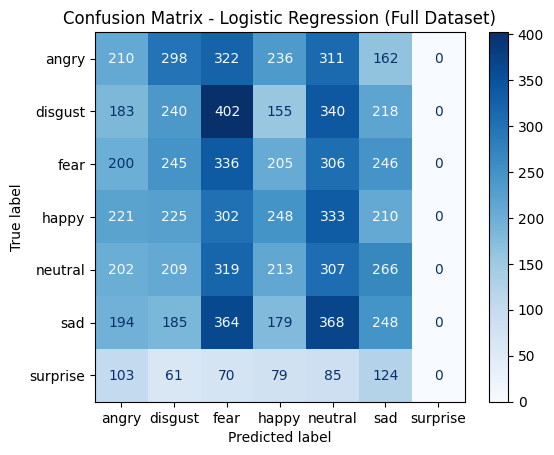

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test_full,
    eval_results_full['Logistic Regression']['pred'],
    cmap=plt.cm.Blues
)
plt.title("Confusion Matrix - Logistic Regression (Full Dataset)")
plt.show()

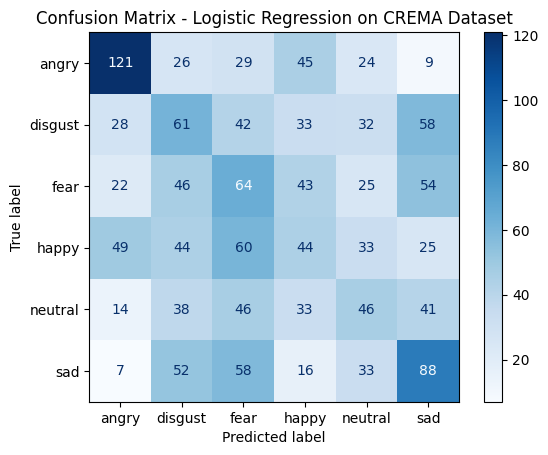

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test_crema,
    eval_results_crema['Logistic Regression (CREMA)']['pred'],
    cmap=plt.cm.Blues
)
plt.title("Confusion Matrix - Logistic Regression on CREMA Dataset")
plt.show()

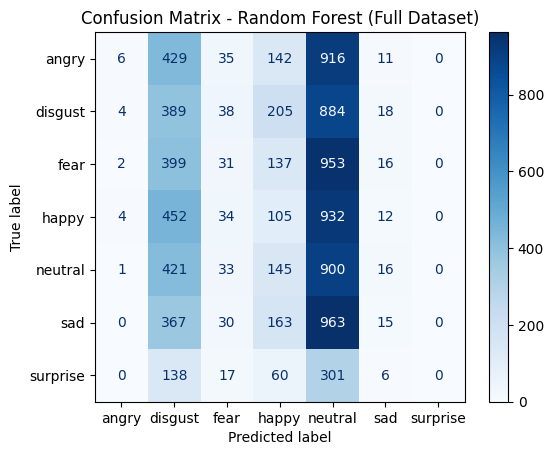

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test_full,
    eval_results_full['Random Forest']['pred'],
    cmap=plt.cm.Blues
)
plt.title("Confusion Matrix - Random Forest (Full Dataset)")
plt.show()

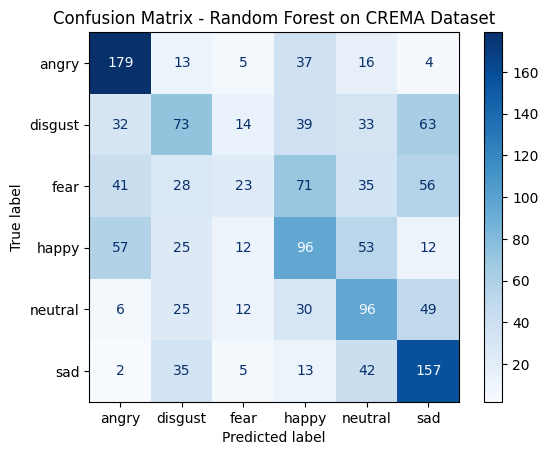

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test_crema,
    eval_results_crema['Random Forest (CREMA)']['pred'],
    cmap=plt.cm.Blues
)
plt.title("Confusion Matrix - Random Forest on CREMA Dataset")
plt.show()

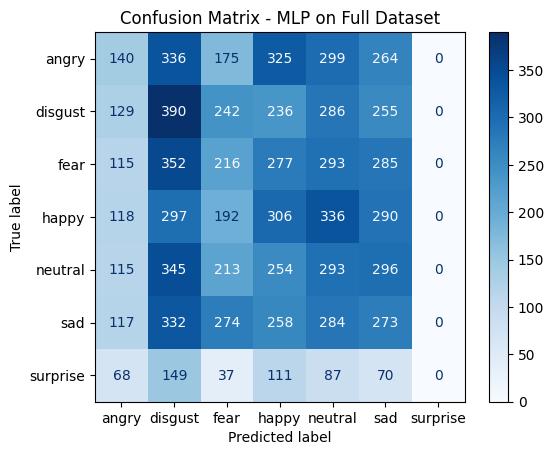

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test_full,
    eval_results_full['MLP Neural Network']['pred'],
    cmap=plt.cm.Blues
)
plt.title("Confusion Matrix - MLP on Full Dataset")
plt.show()

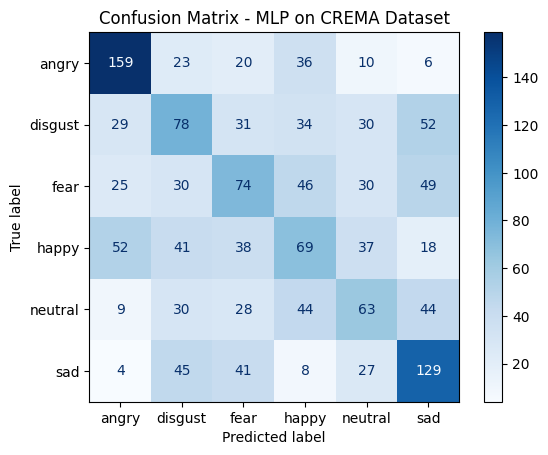

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test_crema,
    eval_results_crema['MLP Neural Network (CREMA)']['pred'],
    cmap=plt.cm.Blues
)
plt.title("Confusion Matrix - MLP on CREMA Dataset")
plt.show()

In [ ]:
"""import librosa
import os

sub_audio_path = "/content/drive/MyDrive/AudioWAV"

def extract_exact_kaggle_features(file_path, target_length=2376):
  y, sr = librosa.load(file_path, sr=16000, duration=2.5)
  mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, hop_length=512)
  log_mel = librosa.power_to_db(mel_spectrogram, ref=np.max)
  flattened = log_mel.flatten()
  if len(flattened) < target_length:
    pad_width = target_length - len(flattened)
    flattened = np.pad(flattened, (0, pad_width), mode='constant', constant_values=flattened.min())
  elif len(flattened) > target_length:
    flattened = flattened[:target_length]
  return flattened

def audio_folder_to_csv(folder_path, output_csv_path):

  features_list = []
  labels_list = []

  emotion_map = {
      'ANG': 'angry',
        'HAP': 'happy',
        'SAD': 'sad',
        'NEU': 'neutral',
        'FEA': 'fear',
        'DIS': 'disgust',
        'PLE': 'surprise'
  }

  file_list = [f for f in os.listdir(folder_path) if f.endswith('.wav')]

  for i, file_name in enumerate(file_list):
    parts = file_name.split('_')
    if len(parts) >= 3:
      emotion_code = parts[2]
      emotion = emotion_map.get(emotion_code, None)
      if not emotion:
        continue
      try:
        full_path = os.path.join(folder_path, file_name)
        feat_vector = extract_exact_kaggle_features(full_path, target_length=2376)
        features_list.append(feat_vector)
        labels_list.append(emotion)
      except Exception as e:
        print(f"Skipping {file_name} due to extraction error: {e}")
      if (i + 1) % 500 == 0:
        print(f"Successfully formatted {i + 1}/{len(file_list)} files...")

  df = pd.DataFrame(features_list)
  df['Emotions'] = labels_list
  df.to_csv(output_csv_path, index=False)
  print(f"Done! Saved perfectly structured dataset with shape {df.shape} to {output_csv_path}")
  return df

output_drive_path = '/content/drive/MyDrive/processed_crema.csv'
processed_df = audio_folder_to_csv(
    folder_path=sub_audio_path,
    output_csv_path=output_drive_path
)

verify_df = pd.read_csv(output_drive_path)
print("File successfully saved to Google Drive!")
print("Shape of saved file:", verify_df.shape) """